# Clasificación de Géneros de Escarabajos con ResNet50

Este notebook implementa un modelo de clasificación de géneros de escarabajos usando una red neuronal convolucional preentrenada (ResNet50) y PyTorch.

## Estructura del Proyecto
- Dataset: 12 géneros de escarabajos + 1 género mixto "unknown_beetle"
- Imágenes: `cropped_beetles/images/` (solo imágenes sin flash)
- **Nota**: Se utilizan únicamente imágenes tomadas sin flash (identificadas con "_s" en el nombre)

In [1]:
# Configuración del entorno para evitar problemas de compatibilidad
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Verificar versiones instaladas
try:
    import numpy as np
    import torch
    import scipy
    import sklearn
    
    print(f"NumPy version: {np.__version__}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"SciPy version: {scipy.__version__}")
    print(f"Scikit-learn version: {sklearn.__version__}")
    
    if hasattr(torch, 'cuda') and torch.cuda.is_available():
        print(f"CUDA available: {torch.cuda.is_available()}")
        print(f"CUDA version: {torch.version.cuda}")
        
    # Verificar compatibilidad de versiones
    import pkg_resources
    from packaging import version
    
    np_version = version.parse(np.__version__)
    min_np_version = version.parse("1.25.2")
    max_np_version = version.parse("2.6.0")
    
    if np_version < min_np_version or np_version >= max_np_version:
        print(f"\n⚠️ ADVERTENCIA: La versión actual de NumPy ({np.__version__}) no es compatible con SciPy.")
        print(f"   Se recomienda una versión entre 1.25.2 y 2.6.0\n")
        print("Comandos para actualizar (ejecutar en terminal):")
        print("conda activate beetles")
        print("conda install numpy=1.25.2 -y")
except ImportError as e:
    print(f"Error al importar: {e}")
    print("\nEs posible que necesites ejecutar estos comandos en una terminal:")
    print("conda activate beetles")
    print("conda install numpy=1.25.2 scipy scikit-learn -y")

NumPy version: 1.25.2
PyTorch version: 2.5.1
SciPy version: 1.16.0
Scikit-learn version: 1.7.2
CUDA available: True
CUDA version: 12.1


C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_27596\1655141021.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms, models
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle


In [3]:

# Configurar la semilla para reproducibilidad
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Verificar si GPU está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")

Utilizando dispositivo: cuda


📸 CARGANDO DATASET DE IMÁGENES
Total de clases: 13
Total de imágenes: 2569


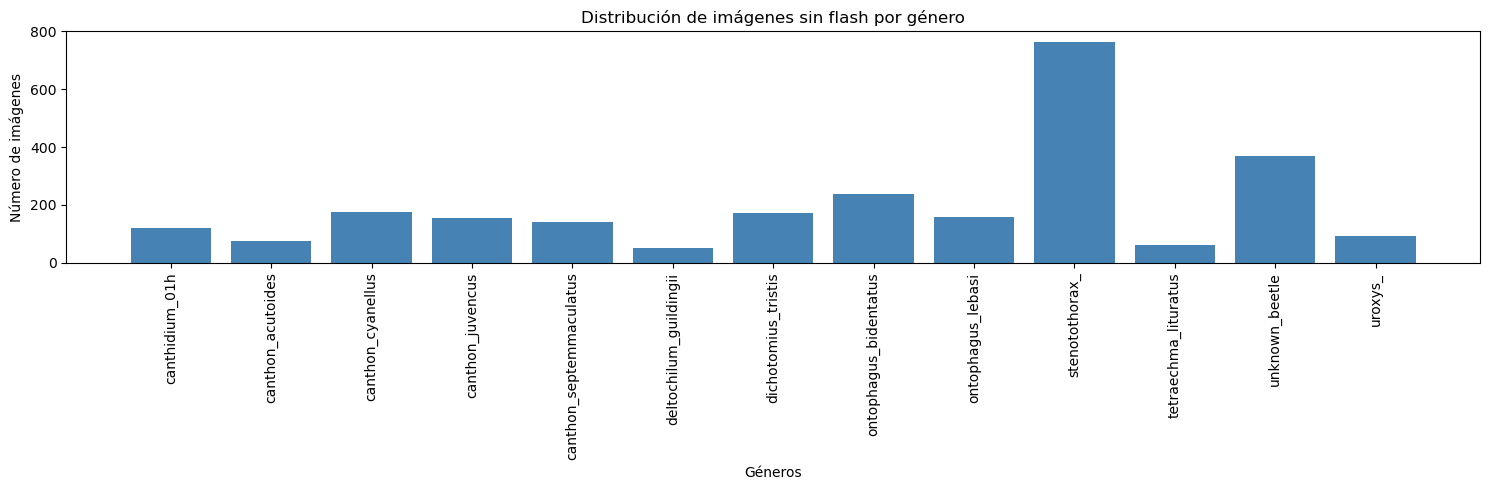

In [4]:
# Definir la clase para nuestro conjunto de datos de escarabajos
class BeetleDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Función para cargar las imágenes y etiquetas
def load_dataset(data_dir='cropped_beetles/images'):
    image_paths = []
    labels = []
    class_names = []
    
    # Obtener las carpetas de géneros (clases)
    for class_idx, genus_folder in enumerate(sorted(os.listdir(data_dir))):
        genus_path = os.path.join(data_dir, genus_folder)
        
        if os.path.isdir(genus_path):
            class_names.append(genus_folder)
            
            # Obtener todas las imágenes de cada género
            for img_file in os.listdir(genus_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(genus_path, img_file)
                    image_paths.append(img_path)
                    labels.append(class_idx)
    
    print(f"Total de clases: {len(class_names)}")
    print(f"Total de imágenes: {len(image_paths)}")
    
    return image_paths, labels, class_names

# Cargar el dataset de imágenes SIN FLASH
print("=" * 60)
print("📸 CARGANDO DATASET DE IMÁGENES")
print("=" * 60)
image_paths, labels, class_names = load_dataset('cropped_beetles/images')

# Mostrar la distribución de clases
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(15, 5))
plt.bar([class_names[i] for i in unique_labels], counts, color='steelblue')
plt.xticks(rotation=90)
plt.xlabel('Géneros')
plt.ylabel('Número de imágenes')
plt.title('Distribución de imágenes sin flash por género')
plt.tight_layout()
plt.show()

# Definir transformaciones para preprocesamiento de imágenes
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
# Preparar para validación cruzada de 5 folds
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f"Total de imágenes: {len(image_paths)}")
print(f"Configurando validación cruzada con {n_folds} folds")
print("=" * 60)


Total de imágenes: 2569
Configurando validación cruzada con 5 folds


## Configuración de Validación Cruzada

Este notebook utiliza **validación cruzada estratificada de 5 folds** para evaluar el modelo de manera más robusta:

- Cada fold contiene aproximadamente 80% de datos para entrenamiento y 20% para validación
- Se mantiene la proporción de clases en cada fold (estratificación)
- Se entrenan 5 modelos independientes, uno por cada fold
- Los pesos de cada modelo se guardan en `model_weights/fold_X_best.pth`
- Al final se obtienen predicciones de todos los datos utilizando el fold correspondiente

In [6]:
# Crear el modelo ResNet50 preentrenado y modificar la capa final
def create_model(num_classes):
    # Cargar el modelo preentrenado
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # Congelar todos los parámetros
    for param in model.parameters():
        param.requires_grad = False
    
    # Obtener el número de características del último layer
    num_ftrs = model.fc.in_features
    
    # Reemplazar el último layer completamente conectado
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    
    # Descongelar las últimas capas para fine-tuning
    for child in list(model.children())[-3:]:
        for param in child.parameters():
            param.requires_grad = True
            
    return model

# Crear el modelo
num_classes = len(class_names)
model = create_model(num_classes)
model = model.to(device)

# Mostrar la arquitectura del modelo
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
# Función para entrenar el modelo en un fold específico
def train_model_fold(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=50, fold_num=1):
    """
    Entrena el modelo para un fold específico
    """
    # Listas para almacenar métricas de entrenamiento
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    # Mejor precisión de validación para guardar el mejor modelo
    best_val_acc = 0.0
    
    print(f"\n{'='*60}")
    print(f"🔄 ENTRENANDO FOLD {fold_num}/{n_folds}")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        # Fase de entrenamiento
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Poner a cero los gradientes
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            # Backward pass y optimización
            loss.backward()
            optimizer.step()
            
            # Estadísticas
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_loss = running_loss / total
        epoch_acc = running_corrects.double() / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc.item())
        
        # Fase de validación
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        # No calcular gradientes en la validación
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                # Estadísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total += labels.size(0)
                
        val_loss = running_loss / total
        val_acc = running_corrects.double() / total
        val_losses.append(val_loss)
        val_accs.append(val_acc.item())
        
        # Paso del planificador
        scheduler.step(val_loss)
        
        # Imprimir estadísticas cada 10 épocas
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Época {epoch+1}/{num_epochs}: '
                  f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        
        # Guardar el mejor modelo del fold
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            fold_model_path = f'model_weights/fold_{fold_num}_best.pth'
            torch.save(model.state_dict(), fold_model_path)
            if (epoch + 1) % 10 == 0:
                print(f'   ✅ Nuevo mejor modelo guardado: {val_acc:.4f}')
    
    # Cargar el mejor modelo del fold
    model.load_state_dict(torch.load(f'model_weights/fold_{fold_num}_best.pth'))
    
    # Convertir best_val_acc a float si es un tensor
    if torch.is_tensor(best_val_acc):
        best_val_acc = best_val_acc.item()
    
    print(f"\n✅ Fold {fold_num} completado. Mejor precisión: {best_val_acc:.4f}")
    
    return model, train_losses, val_losses, train_accs, val_accs, best_val_acc

# Crear directorio para guardar pesos de cada fold
os.makedirs('model_weights', exist_ok=True)

# Almacenar resultados de todos los folds
fold_results = []
all_fold_predictions = []
all_fold_true_labels = []
all_fold_probabilities = []

# Convertir a arrays numpy para facilitar el indexado
image_paths_array = np.array(image_paths)
labels_array = np.array(labels)


In [8]:
# Ejecutar validación cruzada con 5 folds
for fold_num, (train_idx, val_idx) in enumerate(skf.split(image_paths_array, labels_array), 1):
    
    # Obtener los datos de este fold
    train_paths_fold = image_paths_array[train_idx].tolist()
    val_paths_fold = image_paths_array[val_idx].tolist()
    train_labels_fold = labels_array[train_idx].tolist()
    val_labels_fold = labels_array[val_idx].tolist()
    
    print(f"\n{'='*60}")
    print(f"📊 FOLD {fold_num}/{n_folds}")
    print(f"{'='*60}")
    print(f"Imágenes de entrenamiento: {len(train_paths_fold)}")
    print(f"Imágenes de validación: {len(val_paths_fold)}")
    
    # Calcular pesos para manejar el desbalance de clases
    class_counts = np.bincount(train_labels_fold)
    class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    sample_weights = class_weights[train_labels_fold]
    
    # Crear un WeightedRandomSampler para el conjunto de entrenamiento
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_labels_fold),
        replacement=True
    )
    
    # Crear conjuntos de datos para este fold
    train_dataset = BeetleDataset(train_paths_fold, train_labels_fold, transform=transform_train)
    val_dataset = BeetleDataset(val_paths_fold, val_labels_fold, transform=transform_val)
    
    # Crear data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        sampler=sampler,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    # Crear un nuevo modelo para este fold
    model = create_model(num_classes)
    model = model.to(device)
    
    # Definir la función de pérdida y el optimizador
    class_weights_tensor = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1, verbose=False)
    
    # Entrenar el modelo para este fold
    model, train_losses, val_losses, train_accs, val_accs, best_val_acc = train_model_fold(
        model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=50, fold_num=fold_num
    )
    
    # Evaluar el modelo en el conjunto de validación
    model.eval()
    fold_predictions = []
    fold_true_labels = []
    fold_probabilities = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            fold_predictions.extend(preds.cpu().numpy())
            fold_true_labels.extend(labels.cpu().numpy())
            fold_probabilities.extend(probabilities.cpu().numpy())
    
    # Almacenar resultados de este fold
    fold_results.append({
        'fold': fold_num,
        'best_val_acc': best_val_acc,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'model_path': f'model_weights/fold_{fold_num}_best.pth'
    })
    
    all_fold_predictions.extend(fold_predictions)
    all_fold_true_labels.extend(fold_true_labels)
    all_fold_probabilities.extend(fold_probabilities)

# Resumen de todos los folds
print("\n" + "="*60)
print("📈 RESUMEN DE VALIDACIÓN CRUZADA")
print("="*60)
for result in fold_results:
    print(f"Fold {result['fold']}: Mejor Precisión = {result['best_val_acc']:.4f}")

mean_acc = np.mean([r['best_val_acc'] for r in fold_results])
std_acc = np.std([r['best_val_acc'] for r in fold_results])
print(f"\n✅ Precisión promedio: {mean_acc:.4f} ± {std_acc:.4f}")



📊 FOLD 1/5
Imágenes de entrenamiento: 2055
Imágenes de validación: 514

🔄 ENTRENANDO FOLD 1/5



c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Época 1/50: Train Loss: 1.2009, Train Acc: 0.4701, Val Loss: 1.4079, Val Acc: 0.4650
Época 10/50: Train Loss: 0.0864, Train Acc: 0.9367, Val Loss: 0.4761, Val Acc: 0.8560
Época 10/50: Train Loss: 0.0864, Train Acc: 0.9367, Val Loss: 0.4761, Val Acc: 0.8560
Época 20/50: Train Loss: 0.0342, Train Acc: 0.9800, Val Loss: 0.4779, Val Acc: 0.8872
Época 30/50: Train Loss: 0.0319, Train Acc: 0.9762, Val Loss: 0.4691, Val Acc: 0.8930
Época 40/50: Train Loss: 0.0333, Train Acc: 0.9781, Val Loss: 0.4604, Val Acc: 0.8949
Época 50/50: Train Loss: 0.0346, Train Acc: 0.9766, Val Loss: 0.4585, Val Acc: 0.8891

✅ Fold 1 completado. Mejor precisión: 0.8969


C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_27596\233618571.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'model_weights/fold_


📊 FOLD 2/5
Imágenes de entrenamiento: 2055
Imágenes de validación: 514

🔄 ENTRENANDO FOLD 2/5

Época 1/50: Train Loss: 1.0836, Train Acc: 0.4808, Val Loss: 1.5945, Val Acc: 0.3969
Época 10/50: Train Loss: 0.0829, Train Acc: 0.9426, Val Loss: 0.5791, Val Acc: 0.8035
Época 20/50: Train Loss: 0.0335, Train Acc: 0.9742, Val Loss: 0.4838, Val Acc: 0.8560
Época 30/50: Train Loss: 0.0361, Train Acc: 0.9771, Val Loss: 0.4563, Val Acc: 0.8619
   ✅ Nuevo mejor modelo guardado: 0.8619
Época 40/50: Train Loss: 0.0340, Train Acc: 0.9747, Val Loss: 0.4582, Val Acc: 0.8599
Época 50/50: Train Loss: 0.0312, Train Acc: 0.9752, Val Loss: 0.5060, Val Acc: 0.8541

✅ Fold 2 completado. Mejor precisión: 0.8619

📊 FOLD 3/5
Imágenes de entrenamiento: 2055
Imágenes de validación: 514

🔄 ENTRENANDO FOLD 3/5

Época 1/50: Train Loss: 1.1316, Train Acc: 0.4978, Val Loss: 3.2170, Val Acc: 0.2821
Época 10/50: Train Loss: 0.1337, Train Acc: 0.9255, Val Loss: 0.5772, Val Acc: 0.8619
Época 20/50: Train Loss: 0.0308, Tr

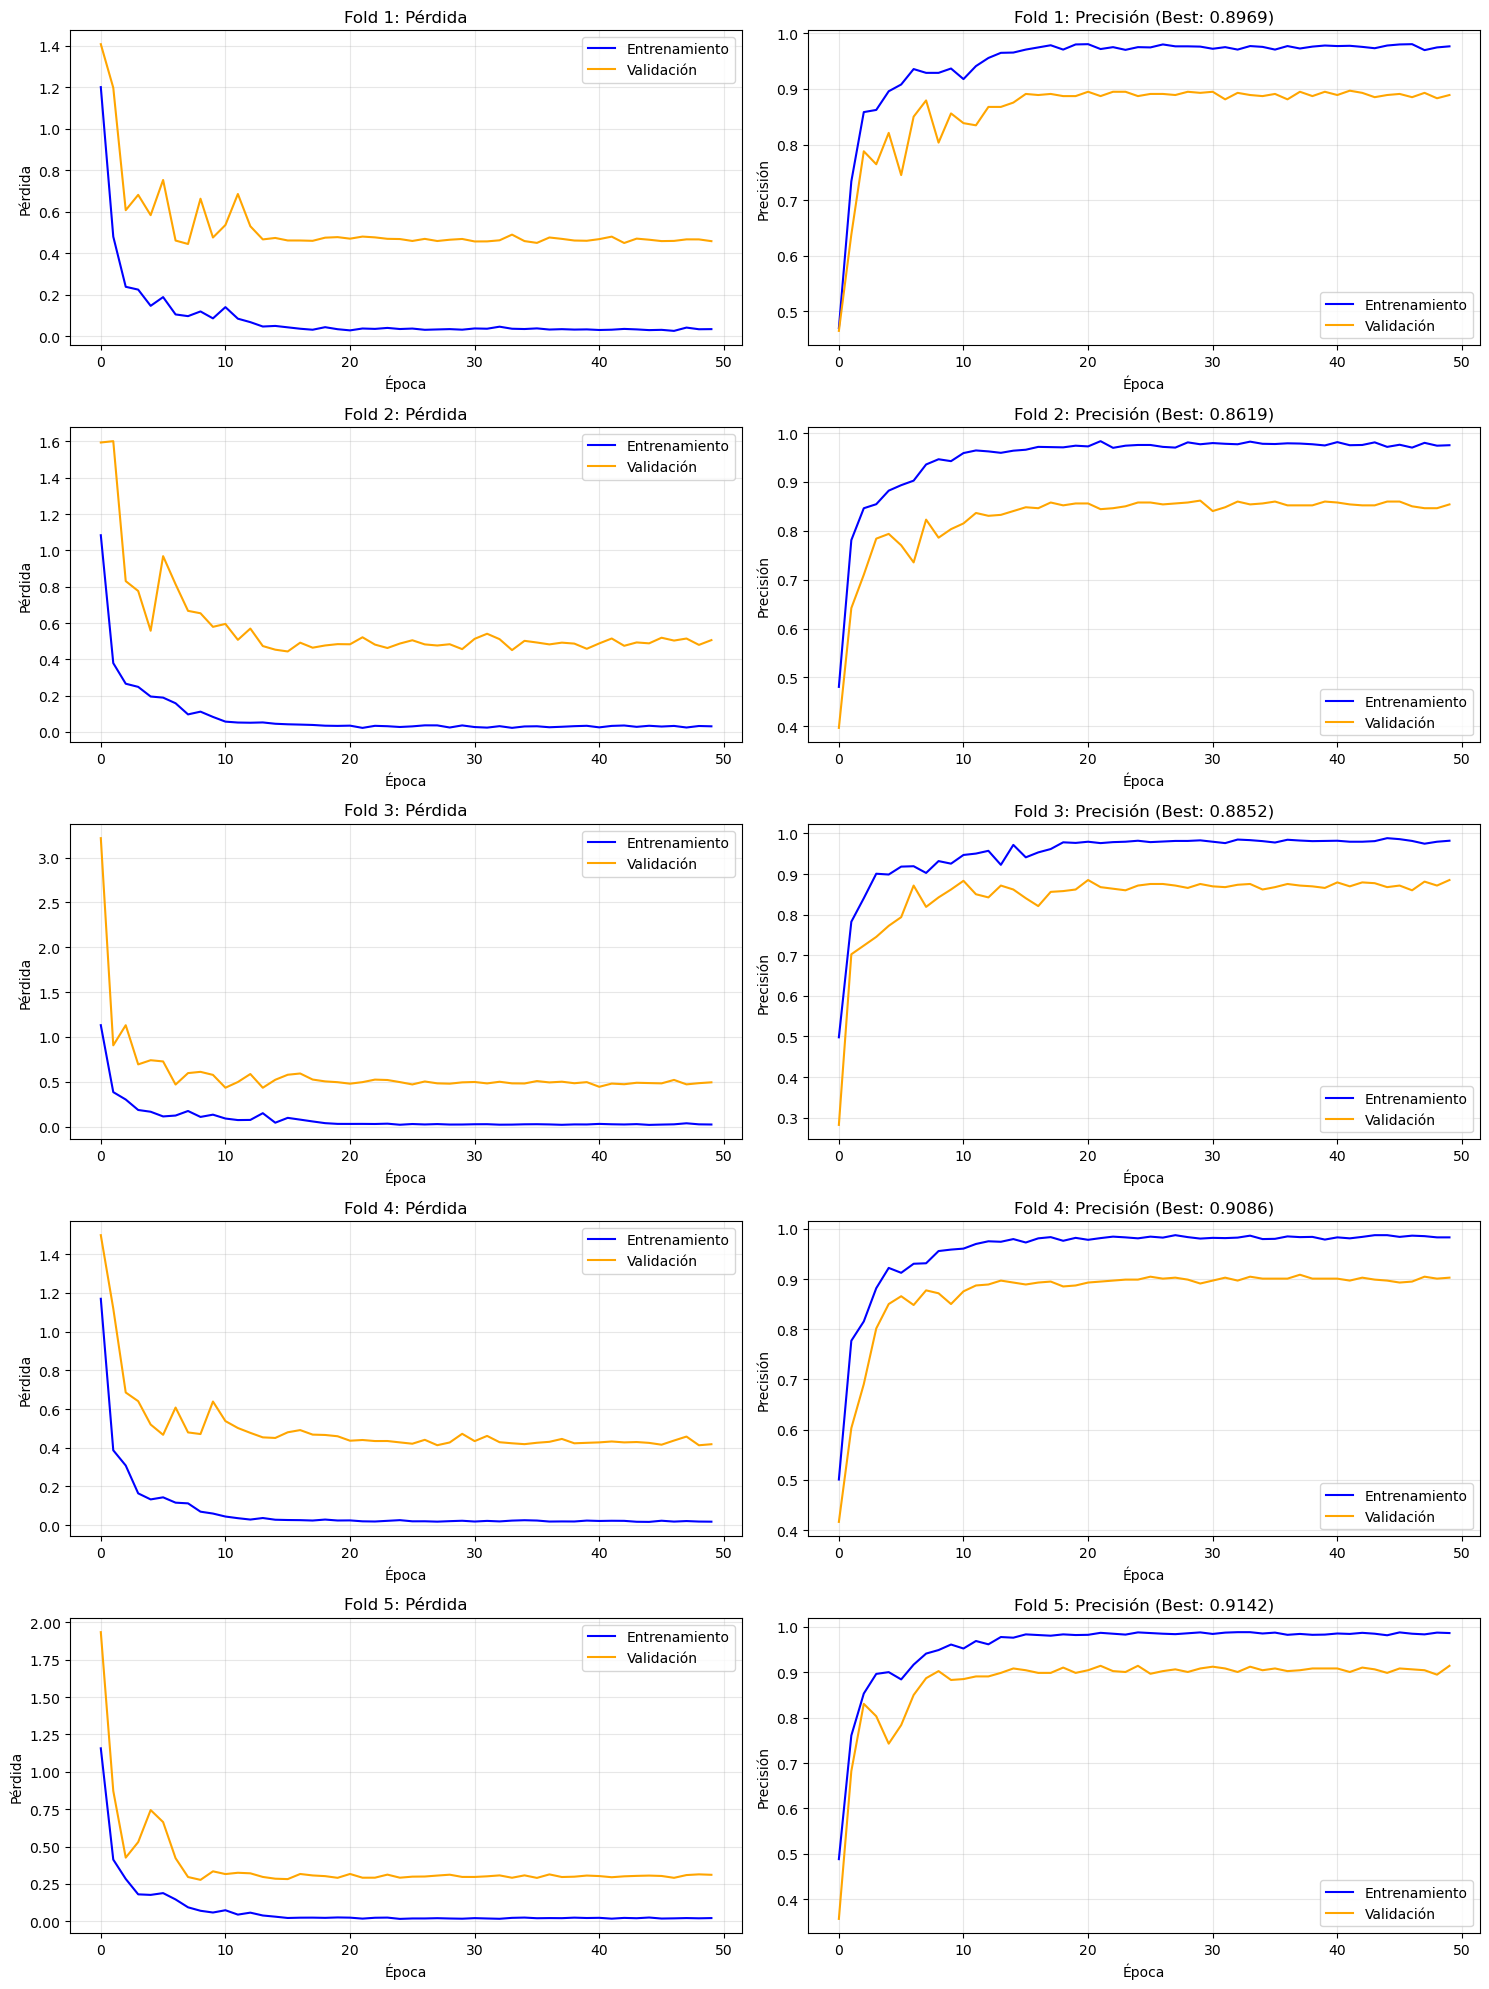

In [10]:
# Visualizar la pérdida y precisión durante el entrenamiento para cada fold
fig, axes = plt.subplots(n_folds, 2, figsize=(15, 4*n_folds))

for idx, result in enumerate(fold_results):
    # Pérdida
    axes[idx, 0].plot(result['train_losses'], label='Entrenamiento', color='blue')
    axes[idx, 0].plot(result['val_losses'], label='Validación', color='orange')
    axes[idx, 0].set_xlabel('Época')
    axes[idx, 0].set_ylabel('Pérdida')
    axes[idx, 0].set_title(f"Fold {result['fold']}: Pérdida")
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Precisión
    axes[idx, 1].plot(result['train_accs'], label='Entrenamiento', color='blue')
    axes[idx, 1].plot(result['val_accs'], label='Validación', color='orange')
    axes[idx, 1].set_xlabel('Época')
    axes[idx, 1].set_ylabel('Precisión')
    axes[idx, 1].set_title(f"Fold {result['fold']}: Precisión (Best: {result['best_val_acc']:.4f})")
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



📊 CALCULANDO CURVAS ROC POR FOLD


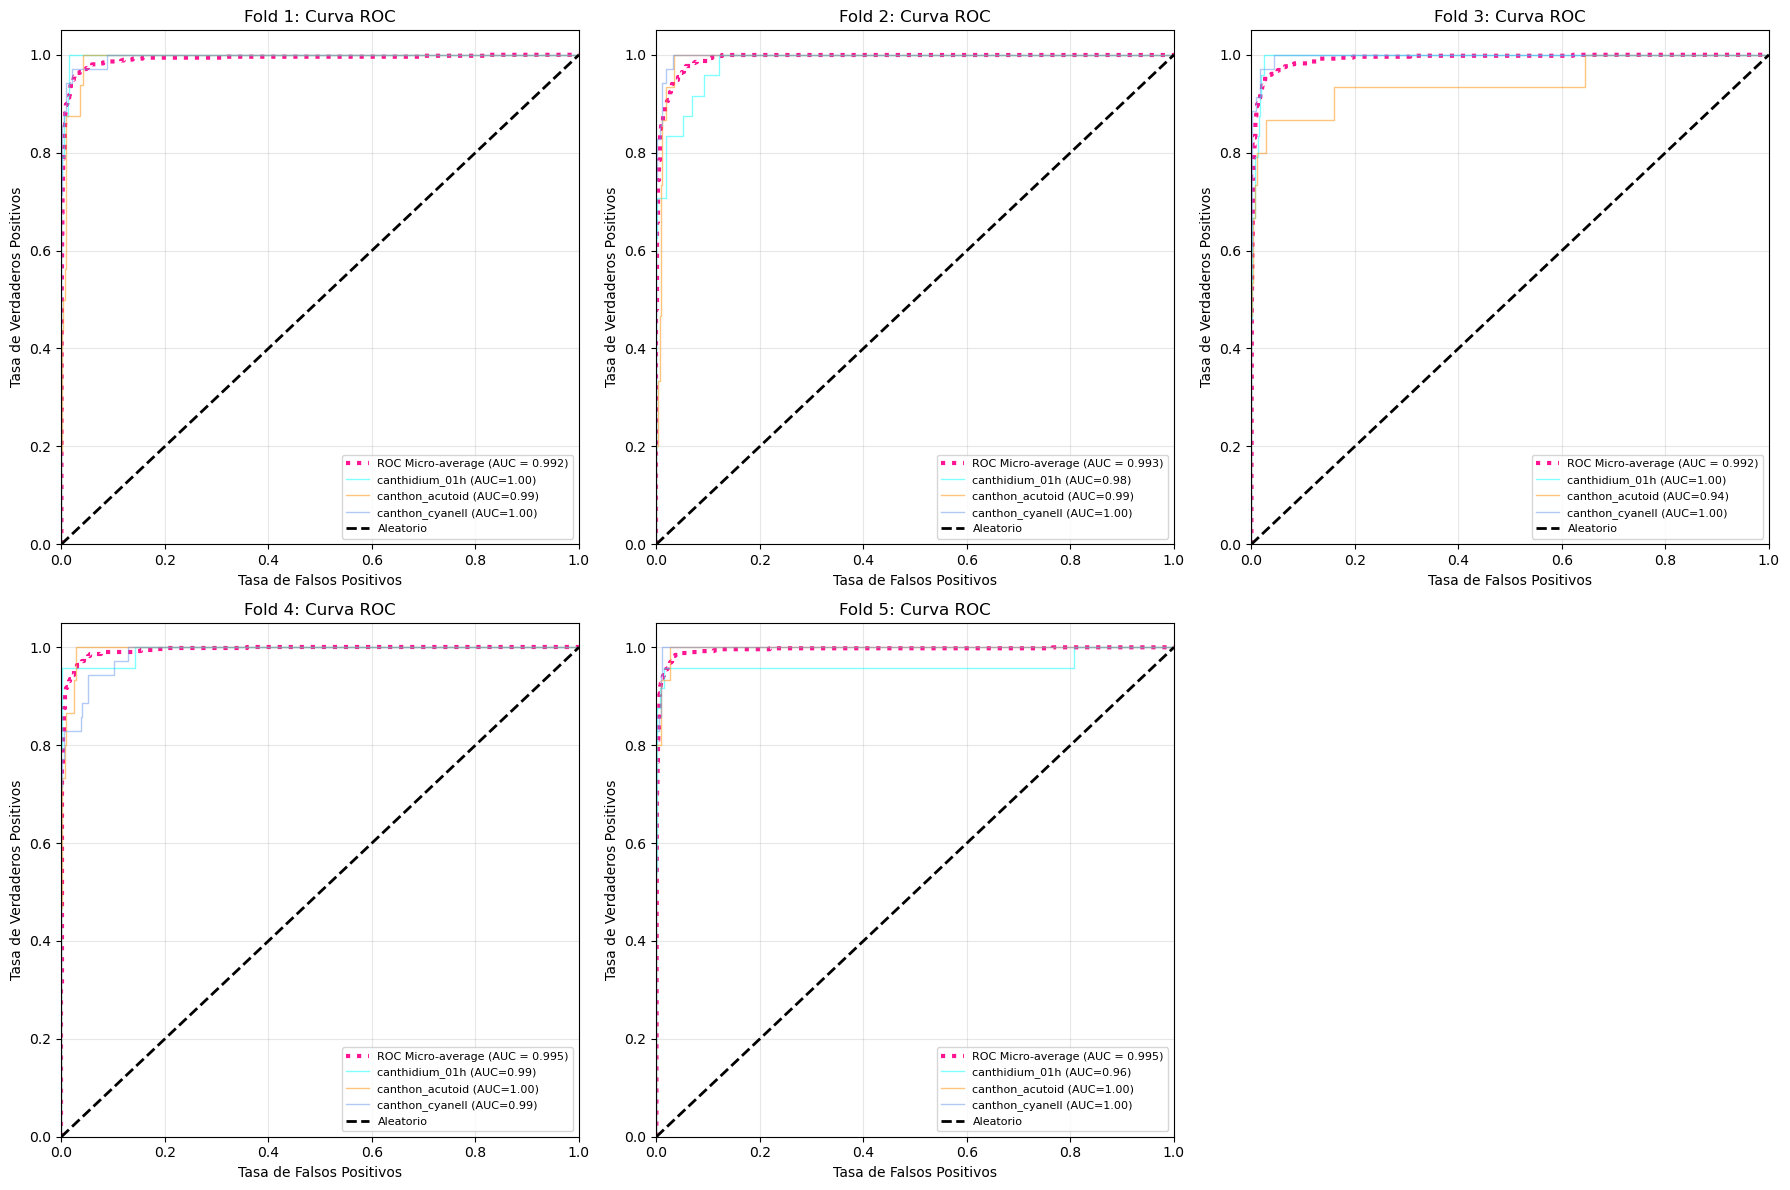

✅ Curvas ROC por fold generadas


In [11]:
# Visualizar curvas ROC para cada fold
print("\n" + "="*60)
print("📊 CALCULANDO CURVAS ROC POR FOLD")
print("="*60)

# Binarizar las etiquetas para el análisis ROC multiclase
y_true_binarized = label_binarize(all_fold_true_labels, classes=list(range(num_classes)))
y_prob_array = np.array(all_fold_probabilities)

# Calcular curvas ROC por fold
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Recorrer cada fold y calcular su curva ROC
fold_start_idx = 0
for fold_idx, result in enumerate(fold_results):
    ax = axes[fold_idx]
    
    # Obtener el número de muestras en este fold
    fold_size = len([idx for idx in range(len(image_paths_array)) 
                     if idx in list(skf.split(image_paths_array, labels_array))[fold_idx][1]])
    
    fold_end_idx = fold_start_idx + fold_size
    
    # Extraer datos de este fold
    y_true_fold = y_true_binarized[fold_start_idx:fold_end_idx]
    y_prob_fold = y_prob_array[fold_start_idx:fold_end_idx]
    
    # Calcular ROC para cada clase
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_fold[:, i], y_prob_fold[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Calcular micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_fold.ravel(), y_prob_fold.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Graficar micro-average
    ax.plot(fpr["micro"], tpr["micro"],
            label=f'ROC Micro-average (AUC = {roc_auc["micro"]:.3f})',
            color='deeppink', linestyle=':', linewidth=3)
    
    # Graficar algunas clases individuales (las 3 primeras)
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(min(3, num_classes)), colors):
        ax.plot(fpr[i], tpr[i], color=color, lw=1, alpha=0.5,
                label=f'{class_names[i][:15]} (AUC={roc_auc[i]:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title(f'Fold {fold_idx + 1}: Curva ROC')
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    fold_start_idx = fold_end_idx

# Ocultar el subplot extra
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Curvas ROC por fold generadas")



📊 CURVA ROC DEL MODELO COMPLETO (TODOS LOS FOLDS)


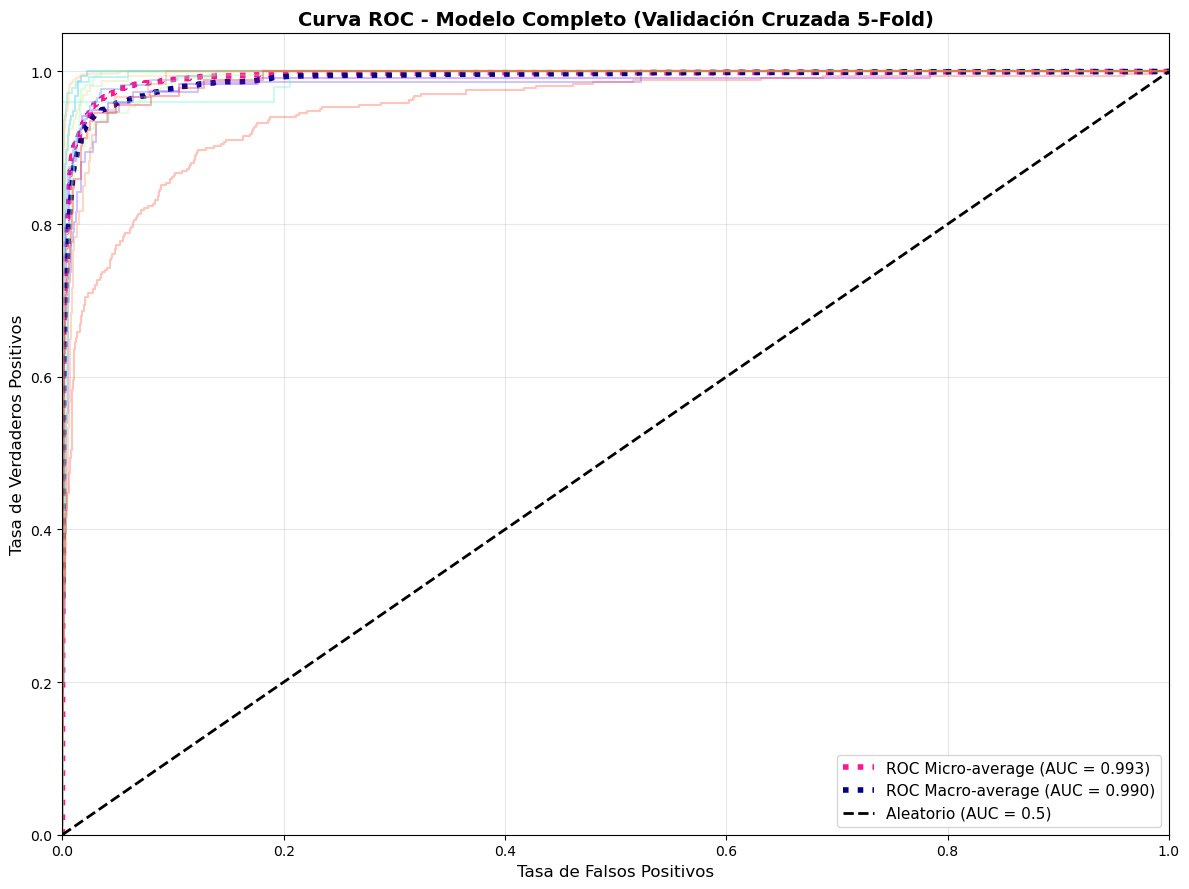


✅ AUC Micro-average: 0.9932
✅ AUC Macro-average: 0.9901


In [12]:
# Visualizar curva ROC del modelo completo (todos los folds combinados)
print("\n" + "="*60)
print("📊 CURVA ROC DEL MODELO COMPLETO (TODOS LOS FOLDS)")
print("="*60)

# Calcular ROC para el modelo completo
fpr_global = dict()
tpr_global = dict()
roc_auc_global = dict()

for i in range(num_classes):
    fpr_global[i], tpr_global[i], _ = roc_curve(y_true_binarized[:, i], y_prob_array[:, i])
    roc_auc_global[i] = auc(fpr_global[i], tpr_global[i])

# Calcular micro-average ROC
fpr_global["micro"], tpr_global["micro"], _ = roc_curve(y_true_binarized.ravel(), y_prob_array.ravel())
roc_auc_global["micro"] = auc(fpr_global["micro"], tpr_global["micro"])

# Calcular macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_global[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr_global[i], tpr_global[i])
mean_tpr /= num_classes
fpr_global["macro"] = all_fpr
tpr_global["macro"] = mean_tpr
roc_auc_global["macro"] = auc(fpr_global["macro"], tpr_global["macro"])

# Crear figura
plt.figure(figsize=(12, 9))

# Graficar micro-average
plt.plot(fpr_global["micro"], tpr_global["micro"],
         label=f'ROC Micro-average (AUC = {roc_auc_global["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=4)

# Graficar macro-average
plt.plot(fpr_global["macro"], tpr_global["macro"],
         label=f'ROC Macro-average (AUC = {roc_auc_global["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=4)

# Graficar curvas ROC de todas las clases (con transparencia)
colors = plt.cm.rainbow(np.linspace(0, 1, num_classes))
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr_global[i], tpr_global[i], color=color, lw=1.5, alpha=0.3)

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Curva ROC - Modelo Completo (Validación Cruzada 5-Fold)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ AUC Micro-average: {roc_auc_global['micro']:.4f}")
print(f"✅ AUC Macro-average: {roc_auc_global['macro']:.4f}")



📊 COMPARACIÓN DE CURVAS ROC DE TODOS LOS FOLDS


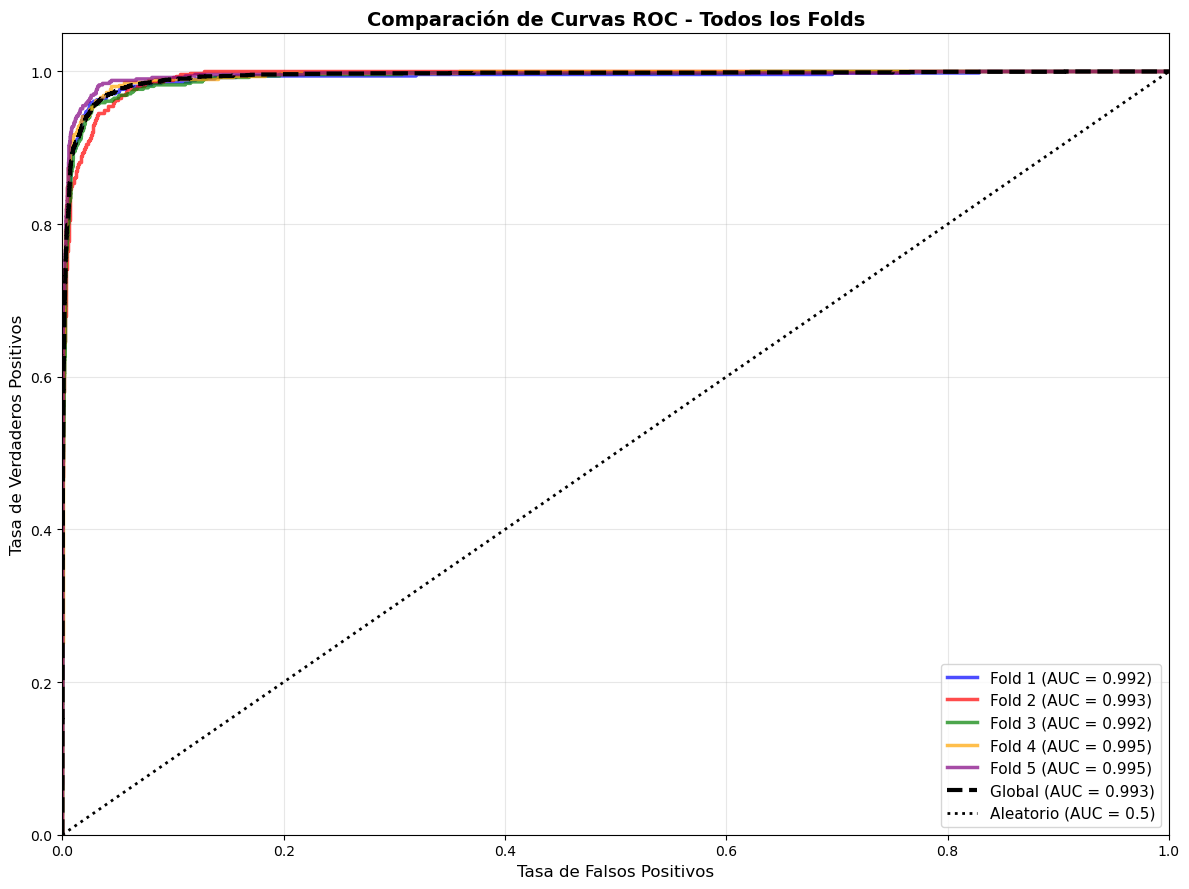


📈 AUC por Fold:
   Fold 1: 0.9915
   Fold 2: 0.9933
   Fold 3: 0.9919
   Fold 4: 0.9946
   Fold 5: 0.9948

   Promedio: 0.9932 ± 0.0013
   Global: 0.9932


In [13]:
# Visualizar todas las curvas ROC de los folds en una sola imagen (comparativa)
print("\n" + "="*60)
print("📊 COMPARACIÓN DE CURVAS ROC DE TODOS LOS FOLDS")
print("="*60)

plt.figure(figsize=(12, 9))

# Colores para cada fold
fold_colors = ['blue', 'red', 'green', 'orange', 'purple']

# Recorrer cada fold y calcular su curva ROC
fold_start_idx = 0
fold_aucs = []

for fold_idx, result in enumerate(fold_results):
    # Obtener el número de muestras en este fold
    fold_size = len([idx for idx in range(len(image_paths_array)) 
                     if idx in list(skf.split(image_paths_array, labels_array))[fold_idx][1]])
    
    fold_end_idx = fold_start_idx + fold_size
    
    # Extraer datos de este fold
    y_true_fold = y_true_binarized[fold_start_idx:fold_end_idx]
    y_prob_fold = y_prob_array[fold_start_idx:fold_end_idx]
    
    # Calcular micro-average ROC para este fold
    fpr_fold, tpr_fold, _ = roc_curve(y_true_fold.ravel(), y_prob_fold.ravel())
    roc_auc_fold = auc(fpr_fold, tpr_fold)
    fold_aucs.append(roc_auc_fold)
    
    # Graficar curva del fold
    plt.plot(fpr_fold, tpr_fold, color=fold_colors[fold_idx], lw=2.5, alpha=0.7,
            label=f'Fold {fold_idx + 1} (AUC = {roc_auc_fold:.3f})')
    
    fold_start_idx = fold_end_idx

# Graficar curva ROC global (todos los folds)
plt.plot(fpr_global["micro"], tpr_global["micro"],
         label=f'Global (AUC = {roc_auc_global["micro"]:.3f})',
         color='black', linestyle='--', linewidth=3)

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k:', lw=2, label='Aleatorio (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Comparación de Curvas ROC - Todos los Folds', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar estadísticas de AUC
print(f"\n📈 AUC por Fold:")
for i, auc_val in enumerate(fold_aucs, 1):
    print(f"   Fold {i}: {auc_val:.4f}")
print(f"\n   Promedio: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"   Global: {roc_auc_global['micro']:.4f}")


In [14]:
# Evaluar el modelo completo usando todas las predicciones de validación cruzada
print("\n" + "="*60)
print("📊 EVALUACIÓN GLOBAL DEL MODELO (TODOS LOS FOLDS)")
print("="*60)

# Usar las predicciones y etiquetas reales de todos los folds
true_labels = all_fold_true_labels
predictions = all_fold_predictions

# Obtener las etiquetas únicas presentes en los datos de validación
unique_labels = np.unique(true_labels)
present_class_names = [class_names[i] for i in unique_labels]

# Calcular métricas
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

print(f"\nMétricas Globales:")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-score (Weighted): {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(true_labels, predictions, 
                          labels=unique_labels,
                          target_names=present_class_names))



📊 EVALUACIÓN GLOBAL DEL MODELO (TODOS LOS FOLDS)

Métricas Globales:
Precisión (Accuracy): 0.8933
Precision (Weighted): 0.8957
Recall (Weighted): 0.8933
F1-score (Weighted): 0.8924

Reporte de clasificación:
                         precision    recall  f1-score   support

         canthidium_01h       0.85      0.87      0.86       120
      canthon_acutoides       0.76      0.76      0.76        76
      canthon_cyanellus       0.86      0.90      0.88       175
       canthon_juvencus       0.91      0.92      0.91       156
canthon_septemmaculatus       0.94      0.96      0.95       141
 deltochilum_guildingii       1.00      0.96      0.98        50
    dichotomius_tristis       0.80      0.96      0.87       171
  ontophagus_bidentatus       0.88      0.89      0.88       237
      ontophagus_lebasi       0.89      0.93      0.91       160
         stenotothorax_       0.98      0.98      0.98       762
   tetraechma_lituratus       0.64      0.75      0.69        60
         u

In [16]:
# Guardar predicciones en formato organizado para comparaciones futuras
import pickle
from datetime import datetime

print("\n")
print("💾 GUARDANDO PREDICCIONES PARA ANÁLISIS COMPARATIVO")


# Crear diccionario con toda la información relevante
predictions_dict = {
    # Información del modelo
    'model_name': 'ResNet50_CrossValidation_5Fold',
    'model_architecture': 'ResNet50',
    'date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    
    # Resultados de validación cruzada
    'predictions': all_fold_predictions,
    'true_labels': all_fold_true_labels,
    'probabilities': all_fold_probabilities,
    
    # Información de clases
    'class_names': class_names,
    'num_classes': num_classes,
    
    # Métricas globales
    'mean_accuracy': mean_acc,
    'std_accuracy': std_acc,
    'global_accuracy': accuracy_score(all_fold_true_labels, all_fold_predictions),
    
    # Resultados por fold
    'fold_results': [
        {
            'fold': r['fold'],
            'best_val_acc': r['best_val_acc'],
            'num_epochs': len(r['train_losses']),
            'model_path': r['model_path']
        }
        for r in fold_results
    ],
    
    # Métricas ROC
    'roc_auc_micro': roc_auc_global['micro'],
    'roc_auc_macro': roc_auc_global['macro'],
    
    # Información adicional
    'total_samples': len(all_fold_true_labels),
    'cv_folds': n_folds,
    'seed': seed
}

# Guardar en formato pickle
pickle_filename = 'predictions_resnet50_cv5.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(predictions_dict, f)

print(f"\n✅ Predicciones guardadas en: '{pickle_filename}'")
print(f"   📊 Total de predicciones: {len(all_fold_predictions)}")
print(f"   🎯 Clases: {num_classes}")
print(f"   📈 Precisión global: {predictions_dict['global_accuracy']:.4f}")
print(f"   📅 Fecha: {predictions_dict['date']}")

# También guardar en formato numpy para facilitar acceso
np.savez('predictions_resnet50_cv5.npz',
         predictions=np.array(all_fold_predictions),
         true_labels=np.array(all_fold_true_labels),
         probabilities=np.array(all_fold_probabilities),
         class_names=np.array(class_names))

print(f"\n✅ También guardado en formato NumPy: 'predictions_resnet50_cv5.npz'")
print("\n" + "="*60)




💾 GUARDANDO PREDICCIONES PARA ANÁLISIS COMPARATIVO

✅ Predicciones guardadas en: 'predictions_resnet50_cv5.pkl'
   📊 Total de predicciones: 2569
   🎯 Clases: 13
   📈 Precisión global: 0.8933
   📅 Fecha: 2025-11-11 16:32:04

✅ También guardado en formato NumPy: 'predictions_resnet50_cv5.npz'



📊 CLASES CON PRECISIÓN > 80%

✅ 10 clases con precisión > 80%:

1. deltochilum_guildingii
   Precision: 100.00%
   Recall:    96.00%
   F1-Score:  0.9796
   Support:   50 imágenes

2. stenotothorax_
   Precision: 98.42%
   Recall:    97.90%
   F1-Score:  0.9816
   Support:   762 imágenes

3. canthon_septemmaculatus
   Precision: 93.75%
   Recall:    95.74%
   F1-Score:  0.9474
   Support:   141 imágenes

4. canthon_juvencus
   Precision: 90.57%
   Recall:    92.31%
   F1-Score:  0.9143
   Support:   156 imágenes

5. ontophagus_lebasi
   Precision: 89.16%
   Recall:    92.50%
   F1-Score:  0.9080
   Support:   160 imágenes

6. ontophagus_bidentatus
   Precision: 87.87%
   Recall:    88.61%
   F1-Score:  0.8824
   Support:   237 imágenes

7. unknown_beetle
   Precision: 86.78%
   Recall:    69.38%
   F1-Score:  0.7711
   Support:   369 imágenes

8. canthon_cyanellus
   Precision: 86.34%
   Recall:    90.29%
   F1-Score:  0.8827
   Support:   175 imágenes

9. canthidium_01h
   Precision: 

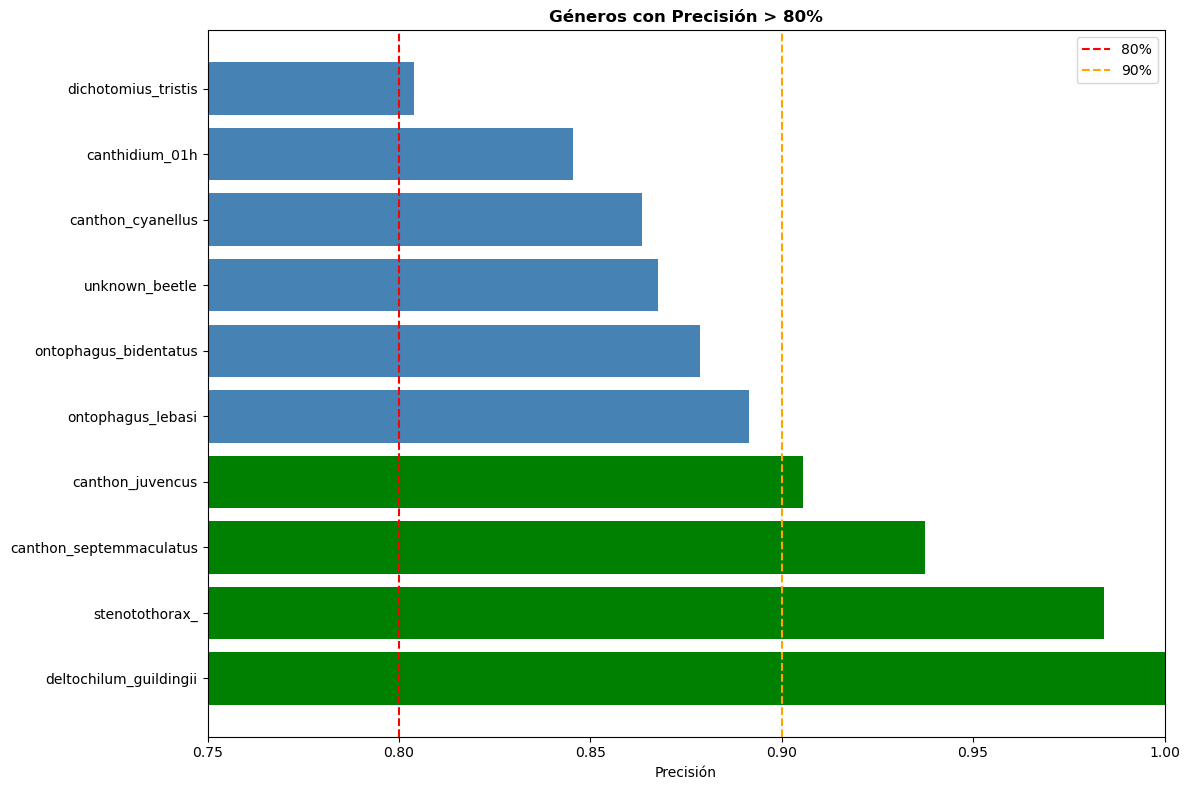

In [17]:
# Filtrar clases con precisión > 80%
print("=" * 70)
print("📊 CLASES CON PRECISIÓN > 80%")
print("=" * 70)

high_precision_classes = []

# Iterar sobre cada clase en el reporte
for class_name in present_class_names:
    if class_name in metricas:
        precision = metricas[class_name]['precision']
        recall = metricas[class_name]['recall']
        f1 = metricas[class_name]['f1-score']
        support = metricas[class_name]['support']
        
        # Filtrar solo las que tienen precisión > 80%
        if precision >= 0.80:
            high_precision_classes.append({
                'Género': class_name,
                'Precision': precision,
                'Recall': recall,
                'F1-Score': f1,
                'Support': int(support)
            })

# Ordenar por precisión descendente
high_precision_classes.sort(key=lambda x: x['Precision'], reverse=True)

# Mostrar resultados
if high_precision_classes:
    print(f"\n✅ {len(high_precision_classes)} clases con precisión > 80%:\n")
    
    for i, clase in enumerate(high_precision_classes, 1):
        print(f"{i}. {clase['Género']}")
        print(f"   Precision: {clase['Precision']*100:.2f}%")
        print(f"   Recall:    {clase['Recall']*100:.2f}%")
        print(f"   F1-Score:  {clase['F1-Score']:.4f}")
        print(f"   Support:   {clase['Support']} imágenes\n")
    
    # Crear DataFrame
    df = pd.DataFrame(high_precision_classes)
    print("\n📋 TABLA RESUMEN:")
    print(df.to_string(index=False))
    
    # Gráfico
    plt.figure(figsize=(12, 8))
    genera = [c['Género'] for c in high_precision_classes]
    precs = [c['Precision'] for c in high_precision_classes]
    colors = ['green' if p > 0.90 else 'steelblue' for p in precs]
    
    plt.barh(range(len(genera)), precs, color=colors)
    plt.yticks(range(len(genera)), genera)
    plt.xlabel('Precisión')
    plt.title('Géneros con Precisión > 80%', fontweight='bold')
    plt.axvline(x=0.80, color='red', linestyle='--', label='80%')
    plt.axvline(x=0.90, color='orange', linestyle='--', label='90%')
    plt.legend()
    plt.xlim(0.75, 1.0)
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ No hay clases con precisión > 80%")

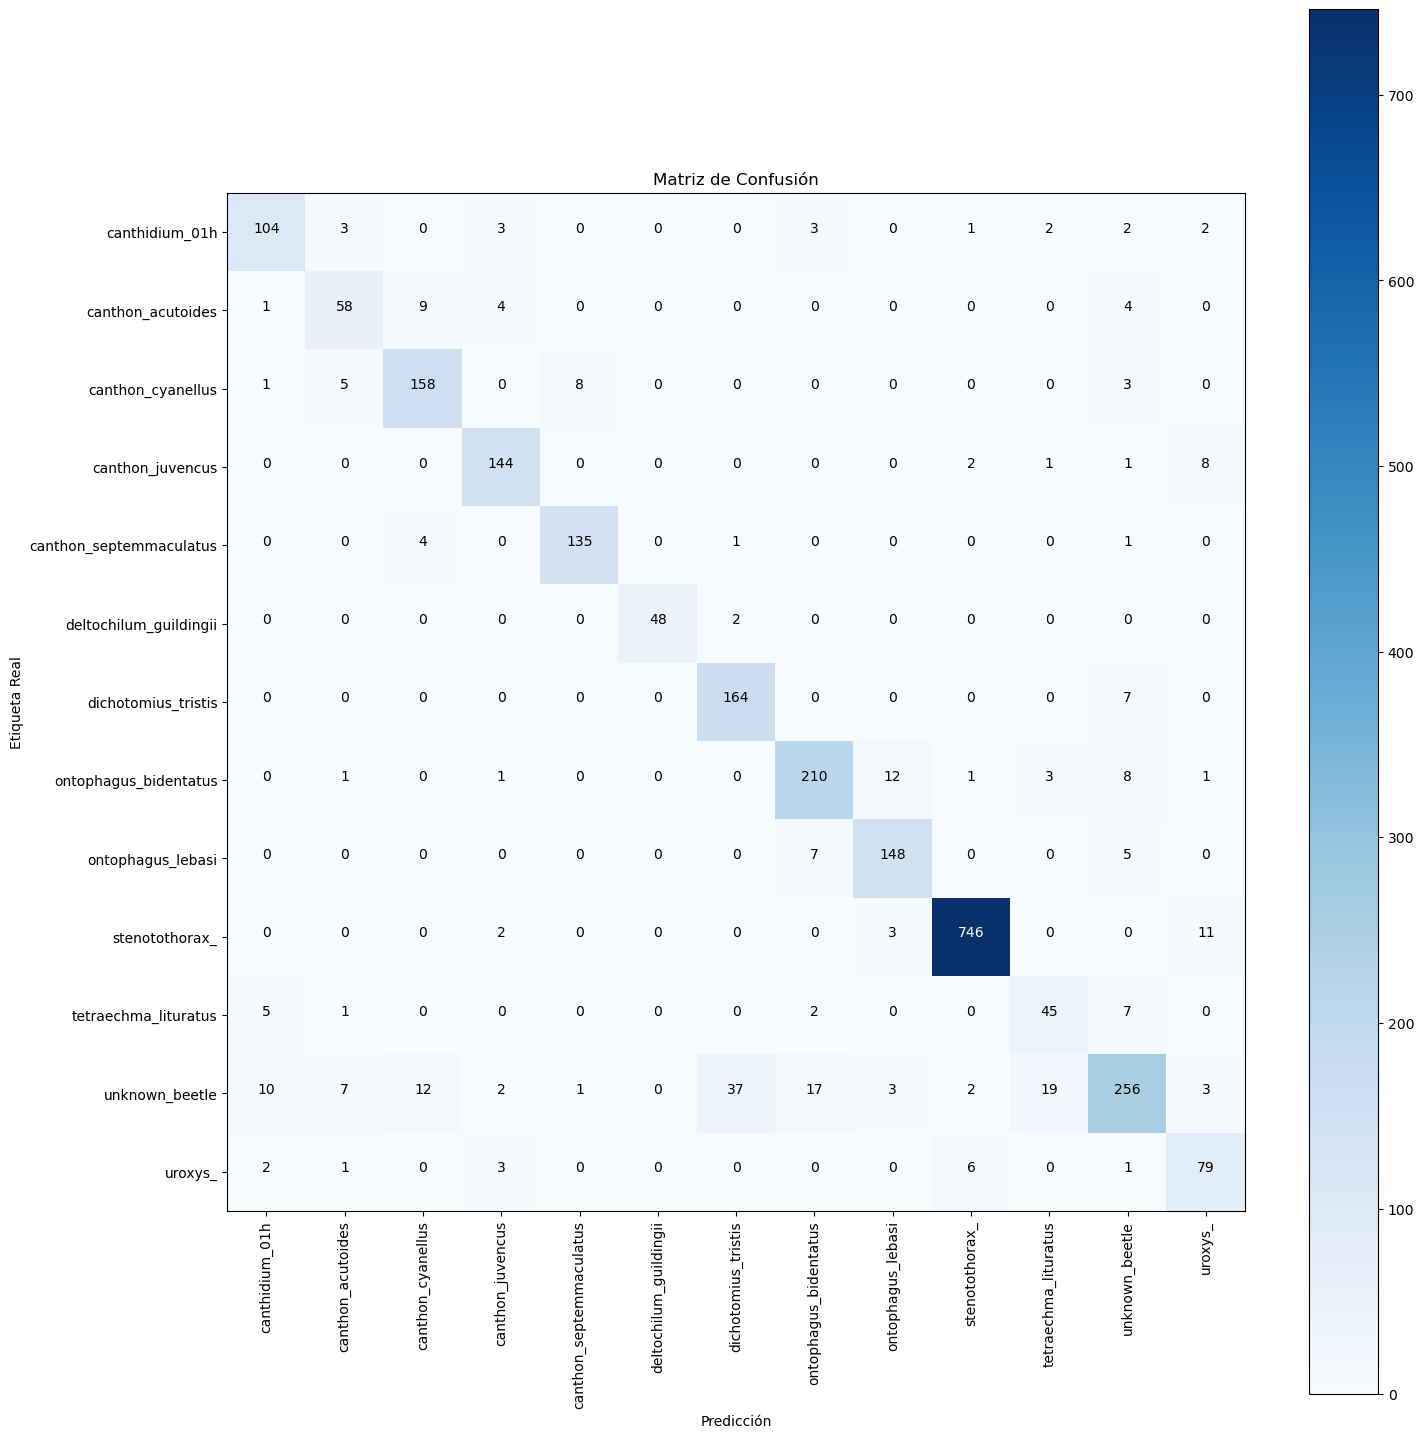

In [19]:
# Visualizar la matriz de confusión
plt.figure(figsize=(15, 15))
cm = confusion_matrix(true_labels, predictions)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()

# Etiquetas para los ejes
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

# Añadir valores numéricos a la matriz
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()


🖼️ VISUALIZANDO PREDICCIONES DEL MEJOR FOLD
Mejor Fold: 5 con precisión: 0.9142


C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_27596\2033191159.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_fold['mode

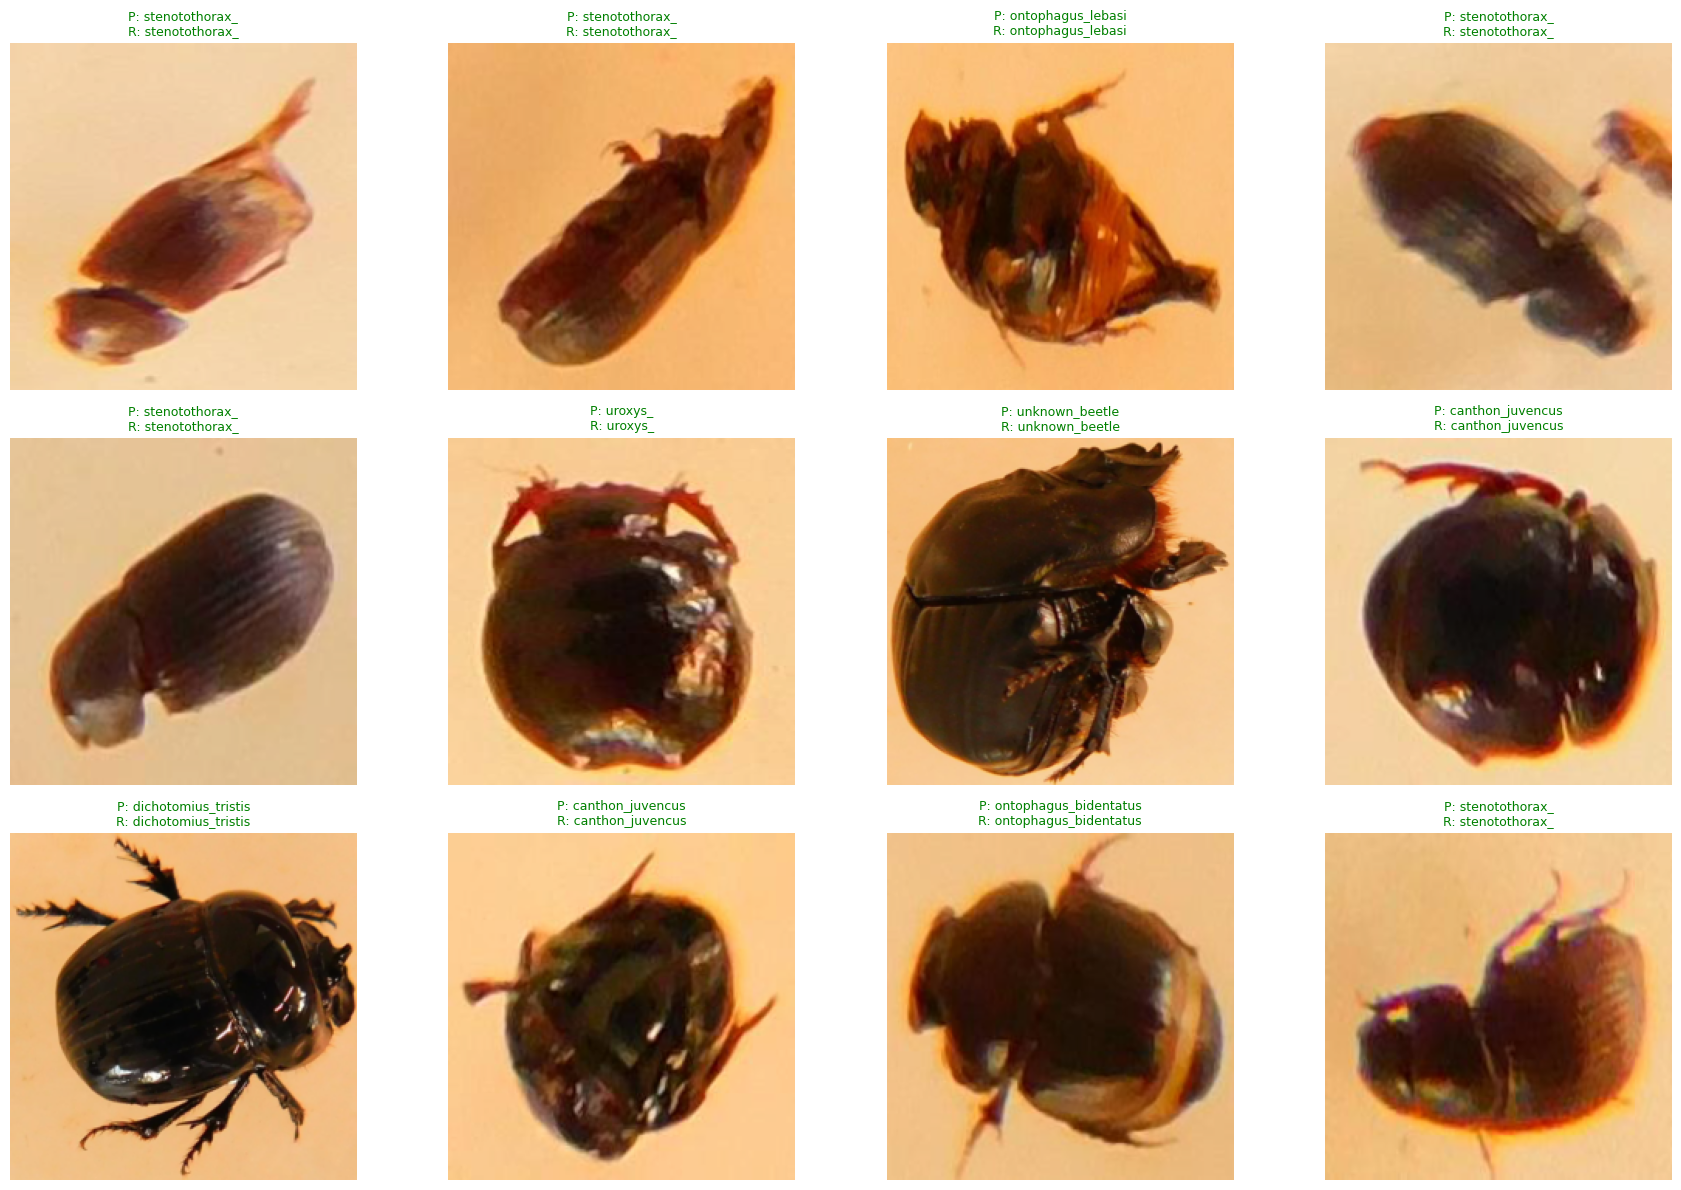

In [20]:
# Visualizar algunas predicciones del mejor fold
print("\n" + "="*60)
print("🖼️ VISUALIZANDO PREDICCIONES DEL MEJOR FOLD")
print("="*60)

# Encontrar el mejor fold
best_fold_idx = np.argmax([r['best_val_acc'] for r in fold_results])
best_fold = fold_results[best_fold_idx]
print(f"Mejor Fold: {best_fold['fold']} con precisión: {best_fold['best_val_acc']:.4f}")

# Cargar el modelo del mejor fold
best_model = create_model(num_classes)
best_model.load_state_dict(torch.load(best_fold['model_path']))
best_model = best_model.to(device)

# Obtener los datos de validación del mejor fold
_, val_idx_best = list(skf.split(image_paths_array, labels_array))[best_fold_idx]
val_paths_best = image_paths_array[val_idx_best].tolist()
val_labels_best = labels_array[val_idx_best].tolist()

val_dataset_best = BeetleDataset(val_paths_best, val_labels_best, transform=transform_val)
val_loader_best = DataLoader(val_dataset_best, batch_size=64, shuffle=True, num_workers=0)

# Visualizar predicciones
def visualize_predictions(model, data_loader, num_images=12):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(18, 12))
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(3, 4, images_so_far)
                
                # Convertir imagen de tensor a numpy para visualización
                img = inputs[j].cpu().permute(1, 2, 0).numpy()
                img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
                img = np.clip(img, 0, 1)
                
                ax.imshow(img)
                
                # Colorear el título según la predicción sea correcta o no
                color = 'green' if preds[j] == labels[j] else 'red'
                ax.set_title(f'P: {class_names[preds[j]]}\nR: {class_names[labels[j]]}', 
                            color=color, fontsize=9)
                plt.axis('off')
                
                if images_so_far == num_images:
                    plt.tight_layout()
                    return
        
        plt.tight_layout()

# Visualizar predicciones
visualize_predictions(best_model, val_loader_best)


In [21]:
# Guardar información completa de validación cruzada
print("\n" + "="*60)
print("💾 GUARDANDO RESULTADOS DE VALIDACIÓN CRUZADA")
print("="*60)

# Guardar el modelo del mejor fold como modelo principal
best_fold_idx = np.argmax([r['best_val_acc'] for r in fold_results])
best_fold = fold_results[best_fold_idx]

torch.save({
    'model_state_dict': best_model.state_dict(),
    'class_names': class_names,
    'best_fold': best_fold['fold'],
    'best_val_acc': best_fold['best_val_acc'],
    'mean_cv_acc': mean_acc,
    'std_cv_acc': std_acc,
    'fold_results': fold_results,
    'all_predictions': all_fold_predictions,
    'all_true_labels': all_fold_true_labels,
    'all_probabilities': all_fold_probabilities
}, 'beetle_classifier_resnet50_cv5.pth')

print(f"✅ Modelo del mejor fold guardado: 'beetle_classifier_resnet50_cv5.pth'")
print(f"   Fold: {best_fold['fold']}")
print(f"   Precisión: {best_fold['best_val_acc']:.4f}")
print(f"\n✅ Pesos individuales de cada fold guardados en 'model_weights/':")
for result in fold_results:
    print(f"   - {result['model_path']} (Acc: {result['best_val_acc']:.4f})")

print(f"\n📊 Resumen de Validación Cruzada:")
print(f"   Precisión promedio: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"   Total de imágenes evaluadas: {len(all_fold_true_labels)}")



💾 GUARDANDO RESULTADOS DE VALIDACIÓN CRUZADA
✅ Modelo del mejor fold guardado: 'beetle_classifier_resnet50_cv5.pth'
   Fold: 5
   Precisión: 0.9142

✅ Pesos individuales de cada fold guardados en 'model_weights/':
   - model_weights/fold_1_best.pth (Acc: 0.8969)
   - model_weights/fold_2_best.pth (Acc: 0.8619)
   - model_weights/fold_3_best.pth (Acc: 0.8852)
   - model_weights/fold_4_best.pth (Acc: 0.9086)
   - model_weights/fold_5_best.pth (Acc: 0.9142)

📊 Resumen de Validación Cruzada:
   Precisión promedio: 0.8934 ± 0.0186
   Total de imágenes evaluadas: 2569



📊 RESUMEN EJECUTIVO - VALIDACIÓN CRUZADA 5-FOLD

📋 Resultados por Fold:
 Fold Mejor Precisión  Épocas                        Modelo
    1          0.8969      50 model_weights/fold_1_best.pth
    2          0.8619      50 model_weights/fold_2_best.pth
    3          0.8852      50 model_weights/fold_3_best.pth
    4          0.9086      50 model_weights/fold_4_best.pth
    5          0.9142      50 model_weights/fold_5_best.pth

📈 Estadísticas Globales:
   • Precisión promedio: 0.8934 ± 0.0186
   • Mejor fold: Fold 5 (0.9142)
   • Peor fold: Fold 2 (0.8619)
   • Total imágenes evaluadas: 2569
   • AUC micro-average: 0.9932
   • AUC macro-average: 0.9901


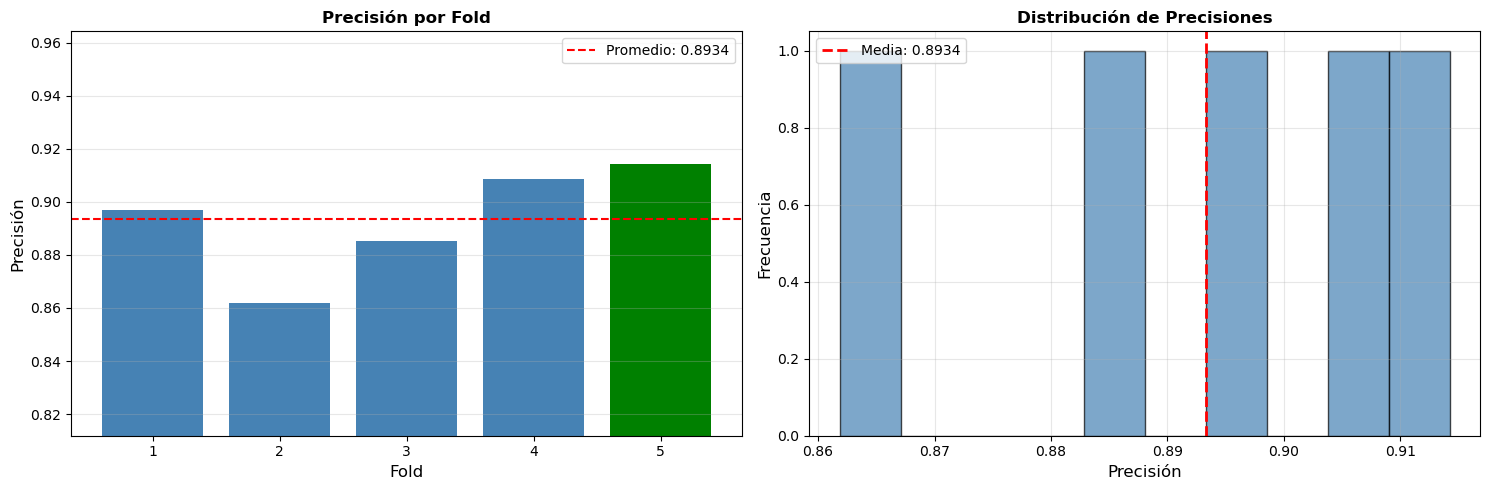

In [22]:
# Resumen ejecutivo de validación cruzada
print("\n" + "="*70)
print("📊 RESUMEN EJECUTIVO - VALIDACIÓN CRUZADA 5-FOLD")
print("="*70)

# Crear tabla con resultados por fold
summary_data = []
for result in fold_results:
    summary_data.append({
        'Fold': result['fold'],
        'Mejor Precisión': f"{result['best_val_acc']:.4f}",
        'Épocas': len(result['train_losses']),
        'Modelo': result['model_path']
    })

df_summary = pd.DataFrame(summary_data)
print("\n📋 Resultados por Fold:")
print(df_summary.to_string(index=False))

print(f"\n📈 Estadísticas Globales:")
print(f"   • Precisión promedio: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"   • Mejor fold: Fold {best_fold['fold']} ({best_fold['best_val_acc']:.4f})")
print(f"   • Peor fold: Fold {min(fold_results, key=lambda x: x['best_val_acc'])['fold']} "
      f"({min(fold_results, key=lambda x: x['best_val_acc'])['best_val_acc']:.4f})")
print(f"   • Total imágenes evaluadas: {len(all_fold_true_labels)}")
print(f"   • AUC micro-average: {roc_auc_global['micro']:.4f}")
print(f"   • AUC macro-average: {roc_auc_global['macro']:.4f}")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Precisión por fold
fold_nums = [r['fold'] for r in fold_results]
fold_accs = [r['best_val_acc'] for r in fold_results]
colors_bar = ['green' if acc == max(fold_accs) else 'steelblue' for acc in fold_accs]

axes[0].bar(fold_nums, fold_accs, color=colors_bar)
axes[0].axhline(y=mean_acc, color='red', linestyle='--', label=f'Promedio: {mean_acc:.4f}')
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('Precisión', fontsize=12)
axes[0].set_title('Precisión por Fold', fontweight='bold')
axes[0].set_ylim([min(fold_accs) - 0.05, max(fold_accs) + 0.05])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Gráfico 2: Distribución de precisiones
axes[1].hist(fold_accs, bins=10, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(x=mean_acc, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_acc:.4f}')
axes[1].set_xlabel('Precisión', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Precisiones', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)


## Función para Predicción

A continuación se muestra cómo puedes utilizar el modelo entrenado para hacer predicciones en nuevas imágenes:

In [ ]:
# Función para hacer predicciones con una nueva imagen usando el mejor modelo
def predict_image(image_path, model, class_names):
    """
    Predice la clase de una imagen usando el modelo entrenado
    """
    # Cargar y preprocesar la imagen
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0)
    
    # Mover al dispositivo correcto
    img_tensor = img_tensor.to(device)
    
    # Modo de evaluación
    model.eval()
    
    # Hacer predicción
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        
        # Calcular probabilidades con softmax
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probabilities, 3, dim=1)
        
    # Mostrar imagen y predicciones
    plt.figure(figsize=(8, 10))
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.title(f'Predicción: {class_names[preds.item()]}', fontweight='bold', fontsize=12)
    plt.axis('off')
    
    # Visualizar las 3 clases con mayor probabilidad
    plt.subplot(2, 1, 2)
    top_probs = top_probs.squeeze().cpu().numpy()
    top_indices = top_indices.squeeze().cpu().numpy()
    
    top_classes = [class_names[i] for i in top_indices]
    
    plt.barh(range(3), top_probs, color='skyblue')
    plt.yticks(range(3), top_classes)
    plt.xlabel('Probabilidad')
    plt.title('Top 3 Predicciones')
    plt.xlim([0, 1])
    plt.tight_layout()
    plt.show()
    
    return preds.item(), probabilities.squeeze().cpu().numpy()

# Función para cargar un modelo de un fold específico
def load_fold_model(fold_number):
    """
    Carga el modelo de un fold específico
    """
    model = create_model(num_classes)
    model_path = f'model_weights/fold_{fold_number}_best.pth'
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    model.eval()
    print(f"✅ Modelo del Fold {fold_number} cargado desde '{model_path}'")
    return model

# Ejemplo de cómo usar las funciones:
# 
# # Cargar modelo de un fold específico
# model_fold_3 = load_fold_model(3)
# 
# # O usar el mejor modelo ya cargado
# # pred_class, probabilities = predict_image("ruta/a/imagen.jpg", best_model, class_names)
